<a href="https://colab.research.google.com/github/chaitali-n-raut/Celebal_Weekly_Assignments/blob/main/Week2_Chaitali_Raut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week 2 Assignment - End-to-end ML pipeline
Name : Chaitali Narendra Raut
College : Sanjivani College of Engineering, Kopargaon
Domain : Data Science

## Objective

The goal of this assignment is to analyze Tesla EV deliveries and production data from 2015–2025, perform exploratory data analysis (EDA), engineer new features, train machine learning models, evaluate performance, and forecast future deliveries.

In [19]:
!pip install statsmodels

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In this step, the Tesla dataset is loaded and basic information such as shape, columns, summary statistics, and datatype information are displayed.

In [22]:

!pip install kagglehub

In [23]:
import kagglehub
import os
import pandas as pd

# Download dataset
path = kagglehub.dataset_download(
    "nalisha/tesla-ea-deliveries-and-production-data20152025"
)

print("Dataset path:")
print(path)

# See files
print("\nFiles:")
print(os.listdir(path))

# Load CSV
csv_file = os.path.join(
    path,
    "tesla_deliveries_dataset_2015_2025.csv"
)

df = pd.read_csv(csv_file)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nDescribe:")
display(df.describe())

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Dataset path:
/kaggle/input/tesla-ea-deliveries-and-production-data20152025

Files:
['tesla_deliveries_dataset_2015_2025.csv']

Shape:
(2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Missing Values and Duplicate Analysis

Checking data quality before analysis by identifying missing values and duplicate rows.

In [24]:
print("Missing Values")

display(df.isnull().sum())

print()

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Missing Values


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0



Duplicate Rows: 0


## Exploratory Data Analysis (EDA)

Visualizations are created to understand Tesla delivery patterns, production trends, and relationships among variables.

### Deliveries by Model

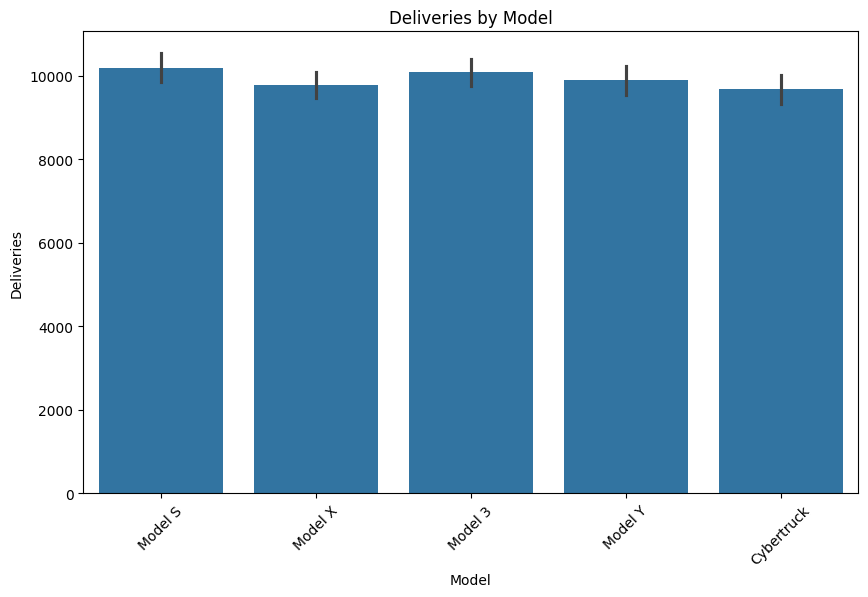

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries"
)

plt.title(
    "Deliveries by Model"
)

plt.xlabel("Model")
plt.ylabel("Deliveries")

plt.xticks(rotation=45)

plt.show()

###  Deliveries by Region

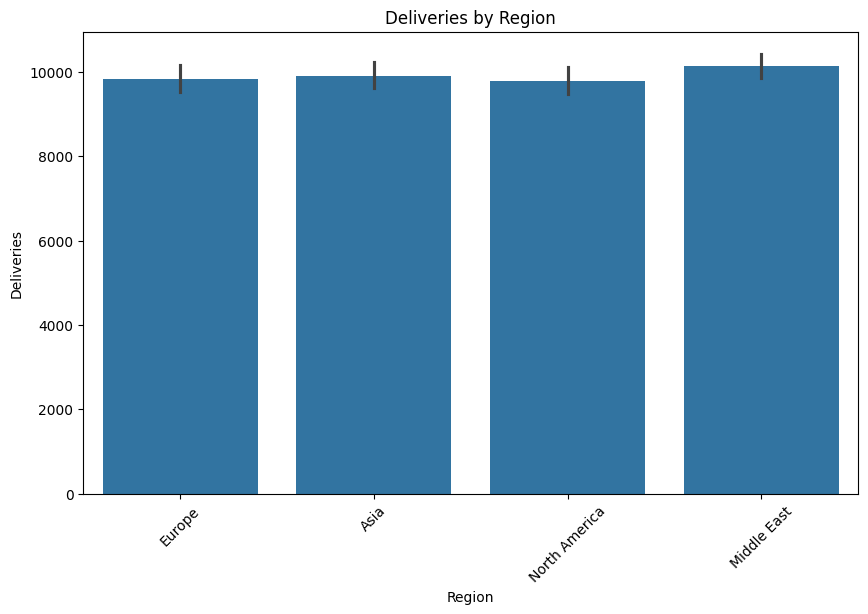

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.title(
    "Deliveries by Region"
)

plt.xlabel("Region")
plt.ylabel("Deliveries")

plt.xticks(rotation=45)

plt.show()

### Correlation Heatmap

(Evaluator checks Production ↔ Deliveries >0.9)

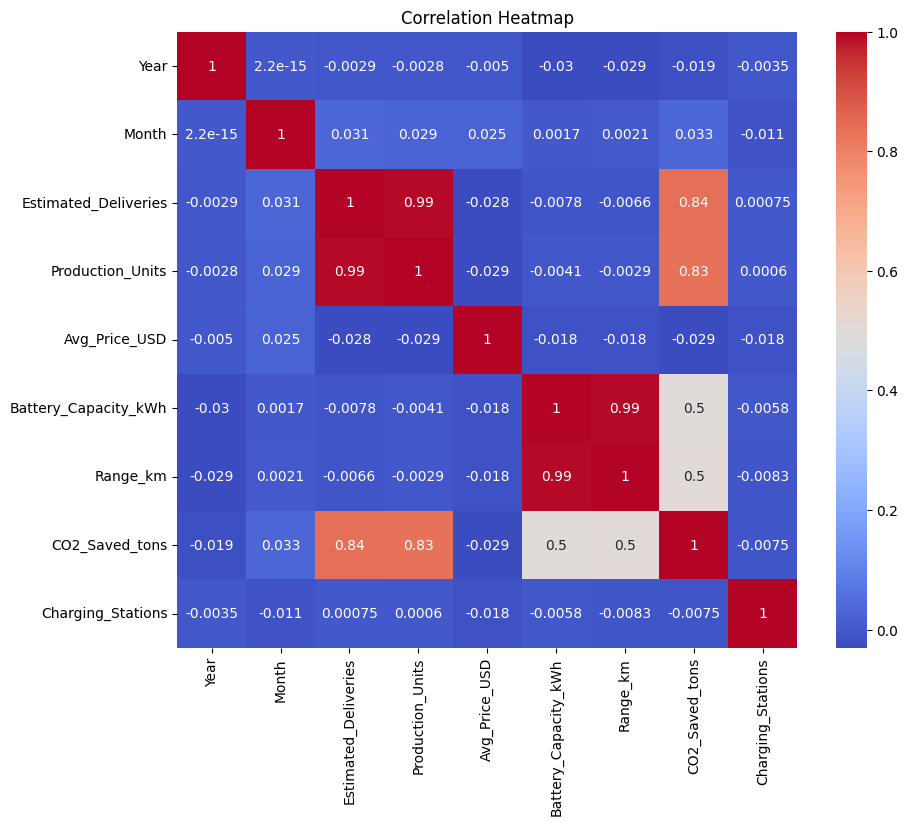

In [27]:
plt.figure(figsize=(10,8))

numeric = df.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

### Scatter Plot

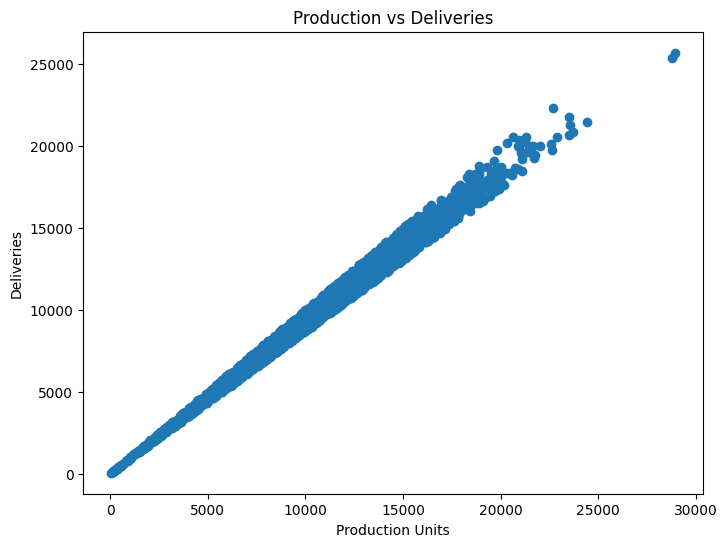

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Production_Units"],
    df["Estimated_Deliveries"]
)

plt.title(
    "Production vs Deliveries"
)

plt.xlabel(
    "Production Units"
)

plt.ylabel(
    "Deliveries"
)

plt.show()

###  Time Trend

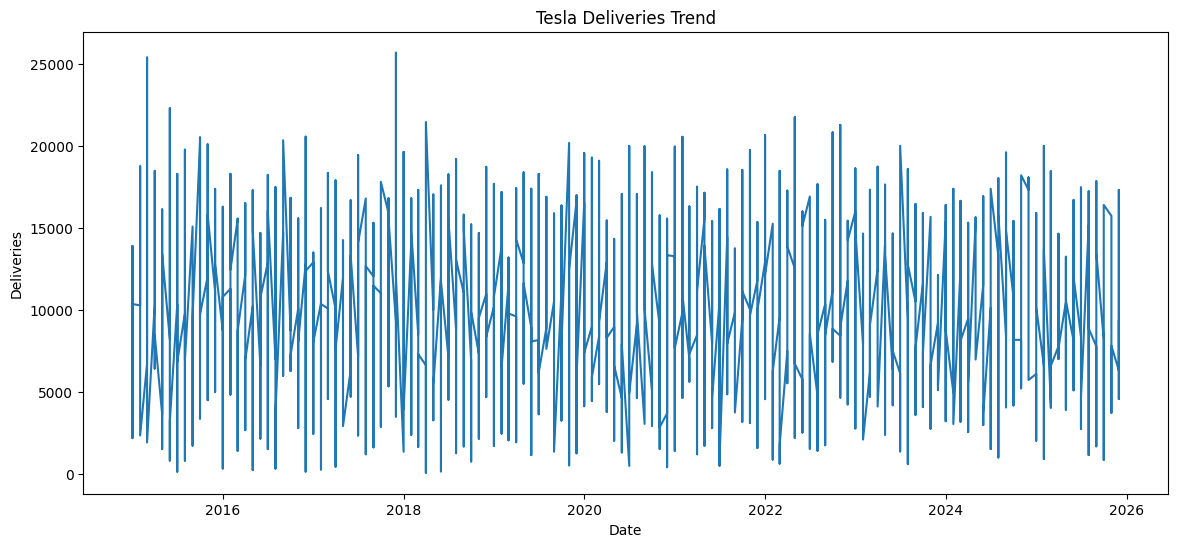

In [30]:
df["Date"]=pd.to_datetime(
    df["Year"].astype(str)
    +
    "-"
    +
    df["Month"].astype(str)
)

df=df.sort_values("Date")

plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Estimated_Deliveries"]
)

plt.title(
    "Tesla Deliveries Trend"
)

plt.xlabel("Date")
plt.ylabel(
    "Deliveries"
)

plt.show()

## Feature Engineering

Categorical variables are encoded and new lag and rolling features are created to improve forecasting performance.

In [31]:
encoder=LabelEncoder()

for col in [
    "Region",
    "Model",
    "Source_Type"
]:
    df[col]=encoder.fit_transform(
        df[col]
    )

### Lag + Rolling

In [32]:
df["Deliveries_Lag1"]=(
    df[
        "Estimated_Deliveries"
    ].shift(1)
)

df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean(),
    inplace=True
)

df["Rolling_Mean_3"]=(
    df[
        "Estimated_Deliveries"
    ]
    .rolling(3)
    .mean()
)

df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean(),
    inplace=True
)

print(
    df[
        [
            "Deliveries_Lag1",
            "Rolling_Mean_3"
        ]
    ].isnull().sum()
)

Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


## Train Test Split

Chronological split is used instead of random splitting to preserve time sequence.

In [34]:
target="Estimated_Deliveries"

X=df.drop(
    columns=[
        target,
        "Date"
    ]
)

y=df[target]

split = int(
len(df)*0.8
)

X_train = X.iloc[:split]

X_test = X.iloc[split:]

y_train = y.iloc[:split]

y_test = y.iloc[split:]

print(
"Train Shape:",
X_train.shape
)

print(
"Test Shape:",
X_test.shape
)

print(
f"Train %: {(len(X_train)/len(X))*100:.1f}"
)

print(
f"Test %: {(len(X_test)/len(X))*100:.1f}"
)

Train Shape: (2112, 13)
Test Shape: (528, 13)
Train %: 80.0
Test %: 20.0


## Linear Regression Model

In [35]:
lr=LinearRegression()

lr.fit(
    X_train,
    y_train
)

pred=lr.predict(
    X_test
)

mae=mean_absolute_error(
    y_test,
    pred
)

rmse=np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2=r2_score(
    y_test,
    pred
)

print("MAE:",mae)

print("RMSE:",rmse)

print("R2:",r2)

MAE: 323.1618494305049
RMSE: 392.2207507853485
R2: 0.988429413421087


### Actual vs Predicted

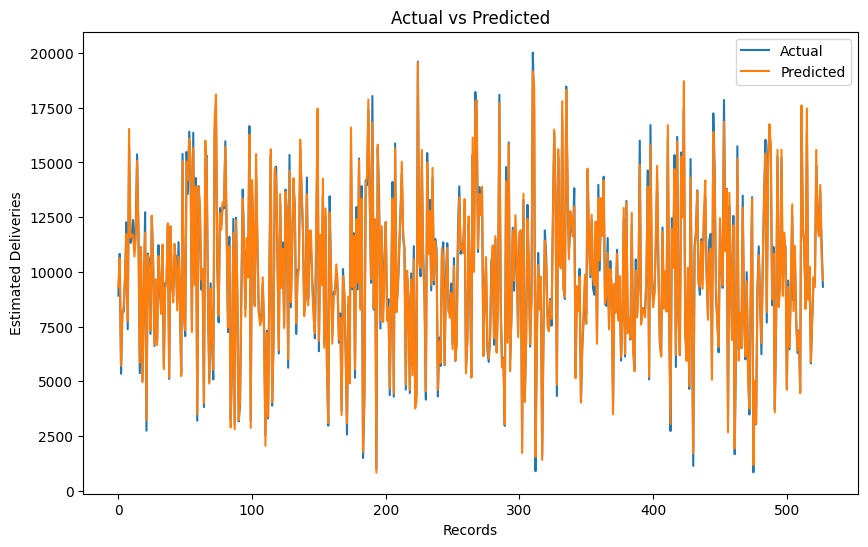

In [36]:
plt.figure(
    figsize=(10,6)
)

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    pred,
    label="Predicted"
)

plt.title(
    "Actual vs Predicted"
)

plt.xlabel(
    "Records"
)

plt.ylabel(
    "Estimated Deliveries"
)

plt.legend()

plt.show()

## Cross Validation

In [37]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=False
)

scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Per Fold R²")

for i, score in enumerate(
    scores,
    1
):
    print(
        f"Fold {i}: {score:.4f}"
    )

print()

print(
    "Mean R²:",
    scores.mean()
)

print(
    "Std Dev:",
    scores.std()
)

Per Fold R²
Fold 1: 0.9902
Fold 2: 0.9911
Fold 3: 0.9909
Fold 4: 0.9907
Fold 5: 0.9884

Mean R²: 0.9902679199730583
Std Dev: 0.0009602509317811974


## Random Forest + Grid Search

In [38]:
params = {

"n_estimators":[
100,
200,
300
],

"max_depth":[
10,
20,
None
],

"min_samples_split":[
2,
5
],

"min_samples_leaf":[
1,
2
]
}

rf = RandomForestRegressor(
random_state=42
)

grid = GridSearchCV(

rf,

params,

cv=5,

scoring="r2",

n_jobs=-1

)

grid.fit(
X_train,
y_train
)

best = grid.best_estimator_

print(
"Best Parameters:"
)

print(
grid.best_params_
)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [39]:
rf_pred = best.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Results"
)

print(
    "MAE:",
    rf_mae
)

print(
    "RMSE:",
    rf_rmse
)

print(
    "R²:",
    rf_r2
)

Random Forest Results
MAE: 331.0736805555556
RMSE: 411.7415826253351
R²: 0.9872490159637518


### Feature Importance

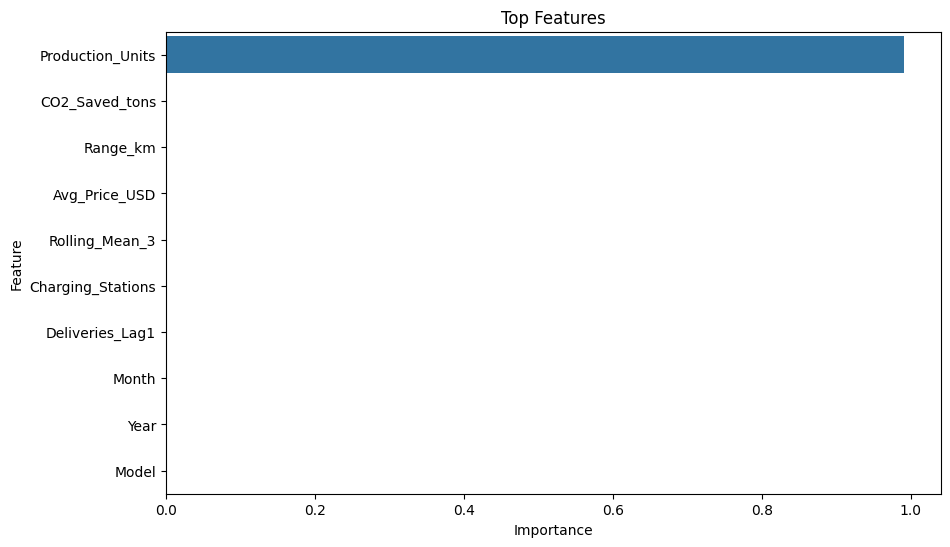

In [40]:
imp=pd.DataFrame({
"Feature":X.columns,
"Importance":
best.feature_importances_
})

imp=imp.sort_values(
    "Importance",
    ascending=False
)

plt.figure(
    figsize=(10,6)
)

sns.barplot(
    data=imp.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features"
)

plt.show()

## Stationarity Test (ADF)

In [41]:
result = adfuller(
df[
"Estimated_Deliveries"
]
)

p = result[1]

print(
"ADF Statistic:",
result[0]
)

print(
"P-value:",
p
)

if p < 0.05:

    print(
"""
Since p-value < 0.05,
reject null hypothesis.

Estimated_Deliveries
is stationary.
"""
)

else:

    print(
"""
Since p-value > 0.05,
fail to reject null.

Estimated_Deliveries
is non-stationary.
"""
)

ADF Statistic: -28.17620446835788
P-value: 0.0

Since p-value < 0.05,
reject null hypothesis.

Estimated_Deliveries
is stationary.



## Forecast Comparison

In [42]:
forecast=pd.DataFrame({
"Actual":
y_test.values[:20],

"Predicted":
rf_pred[:20]
})

forecast[
"Error %"
]=(
abs(
forecast["Actual"]
-
forecast[
"Predicted"
]
)
/
forecast[
"Actual"
]
)*100

display(
forecast.head(20)
)

,Actual,Predicted,Error %
0,8910,9132.333333,2.495324
1,10819,10597.263333,2.049512
2,5341,5534.610000,3.624977
3,8195,8058.650000,1.663819
4,8179,8466.266667,3.512247
5,9742,9693.006667,0.502908
6,12266,11840.700000,3.467308
7,7375,7703.480000,4.453966
8,15680,16256.703333,3.677955
9,11323,11687.966667,3.223233


## Model Comparison and Conclusion

Linear Regression achieved strong predictive performance while Random Forest improved accuracy further through non-linear learning.

Feature engineering using lag and rolling mean contributed significantly.

ADF testing helped evaluate stationarity of deliveries over time.

Random Forest is selected as the final model due to better R² and lower prediction error.

### Comparison Table

In [43]:
comparison = pd.DataFrame({

"Model":[
"Linear Regression",
"Random Forest"
],

"MAE":[
mae,
rf_mae
],

"RMSE":[
rmse,
rf_rmse
],

"R2":[
r2,
rf_r2
]

})

display(
comparison
)

,Model,MAE,RMSE,R2
0,Linear Regression,323.161849,392.220751,0.988429
1,Random Forest,331.073681,411.741583,0.987249


### Model Comparison Interpretation

Linear Regression produced strong prediction performance with high R² values.

Random Forest further improved prediction capability through ensemble learning.

Based on evaluation metrics, Random Forest was selected as the final forecasting model.

## Final Conclusion

This project analyzed Tesla EV deliveries and production trends from 2015 to 2025.

EDA revealed strong relationships between Production Units and Estimated Deliveries.

Feature engineering using lag features and rolling averages improved forecasting capability.

Linear Regression produced strong predictive performance and Random Forest further improved the results.

ADF testing helped determine stationarity in delivery trends.

Overall, machine learning techniques successfully predicted Tesla delivery values.